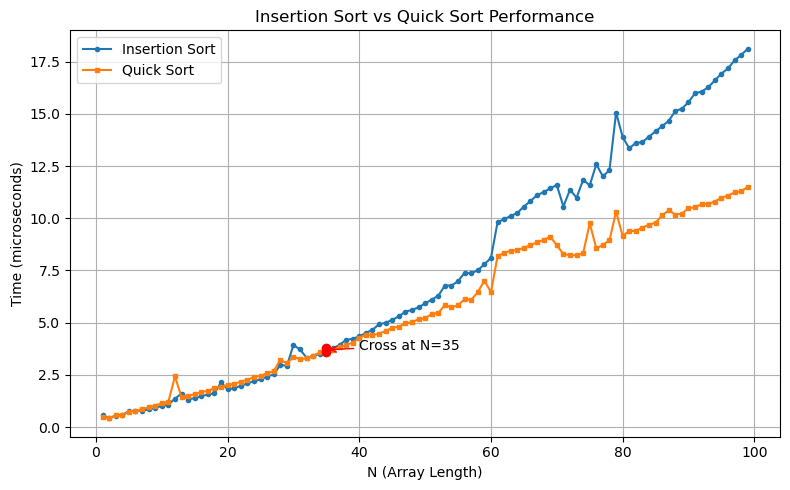

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取 CSV
df = pd.read_csv("result1.csv")

# 提取数据
N = df["N"]
insert_ms = df["insert_ms"]
quick_ms = df["quick_ms"]

# 找交叉点：insert_ms - quick_ms 变号的地方
diff = insert_ms - quick_ms
sign_change = (diff.shift(1) * diff < 0)  # 前后乘积<0说明变号
cross_points = df[sign_change]

if not cross_points.empty:
    # 找到最后一个交叉点
    last_cross = cross_points.iloc[-1]
    cross_N = last_cross["N"]
    cross_insert = last_cross["insert_ms"]
    cross_quick = last_cross["quick_ms"]
else:
    cross_N, cross_insert, cross_quick = None, None, None, None

# 绘图
plt.figure(figsize=(8,5))
plt.plot(N, insert_ms, label="Insertion Sort", marker="o", markersize=3)
plt.plot(N, quick_ms, label="Quick Sort", marker="s", markersize=3)

# 标注交叉点
if cross_N is not None:
    plt.scatter(cross_N, cross_insert, color="red", zorder=5)
    plt.scatter(cross_N, cross_quick, color="red", zorder=5)
    plt.annotate(f"Cross at N={int(cross_N)}",
                 (cross_N, (cross_insert+cross_quick)/2),
                 xytext=(cross_N+5, (cross_insert+cross_quick)/2),
                 arrowprops=dict(arrowstyle="->", color="red"))

plt.xlabel("N (Array Length)")
plt.ylabel("Time (microseconds)")
plt.title("Insertion Sort vs Quick Sort Performance")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


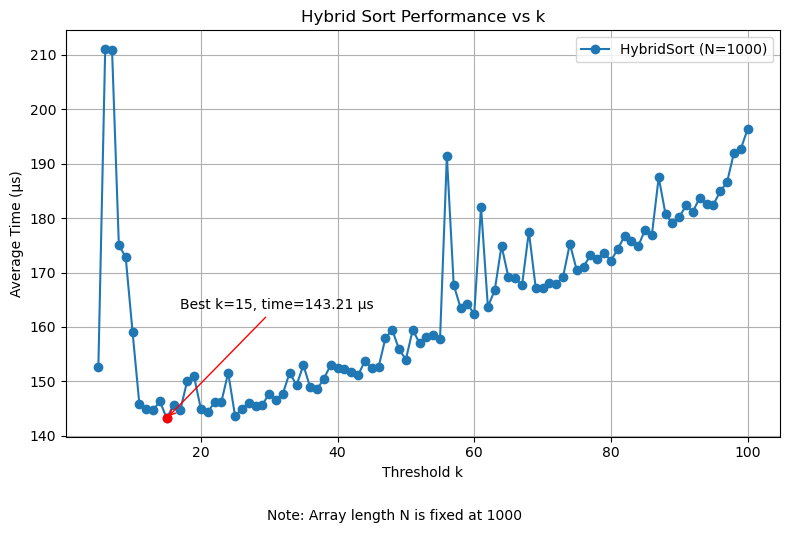

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取 CSV
df = pd.read_csv("result2.csv")

# 提取数据
k = df["k"]
hybrid_ms = df["hybrid_ms"]

# 找到性能最优点（时间最小处）
best_idx = hybrid_ms.idxmin()
best_k = k[best_idx]
best_time = hybrid_ms[best_idx]

# 绘图
plt.figure(figsize=(8,5))
plt.plot(k, hybrid_ms, marker="o", label="HybridSort (N=1000)")

# 标注最优点
plt.scatter(best_k, best_time, color="red", zorder=5)
plt.annotate(f"Best k={best_k}, time={best_time:.2f} μs",
             (best_k, best_time),
             xytext=(best_k+2, best_time+20),
             arrowprops=dict(arrowstyle="->", color="red"))

plt.xlabel("Threshold k")
plt.ylabel("Average Time (μs)")
plt.title("Hybrid Sort Performance vs k")
plt.legend()
plt.grid(True)
plt.tight_layout()

# 在图中加注释说明 N 固定
plt.figtext(0.5, -0.05, "Note: Array length N is fixed at 1000", 
            wrap=True, horizontalalignment='center', fontsize=10)

plt.show()


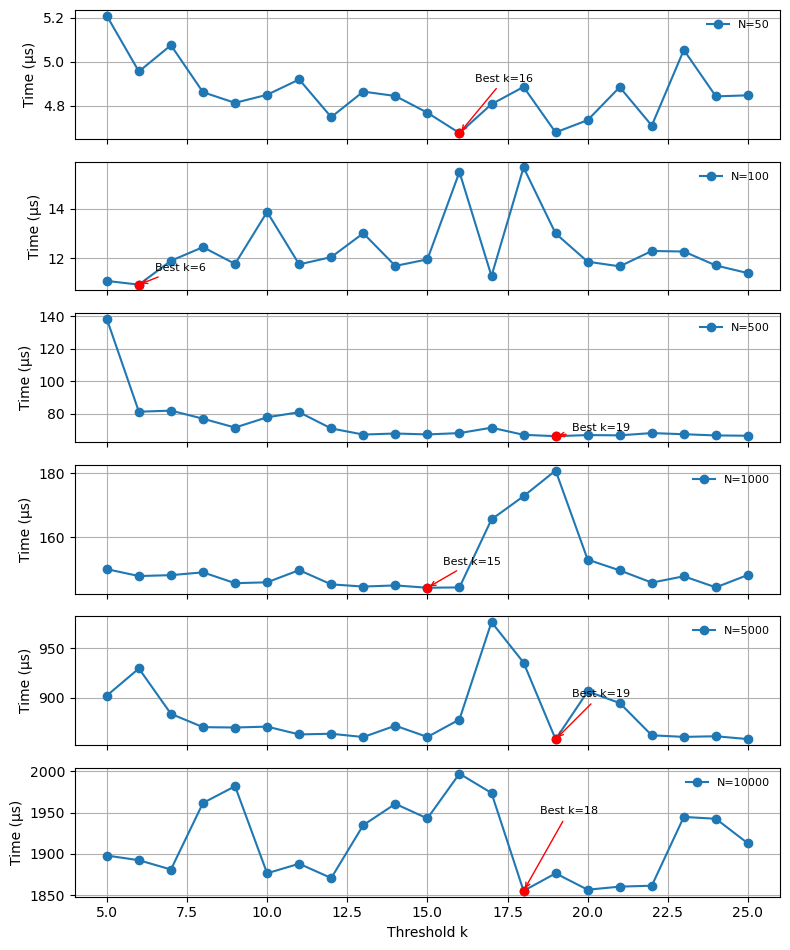

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取 CSV
df = pd.read_csv("result3.csv")

# 找所有不同的 N
Ns = sorted(df["N"].unique())
nrows = len(Ns)

fig, axes = plt.subplots(nrows=nrows, ncols=1, figsize=(8, 1.6*nrows), sharex=True)

if nrows == 1:  # 只有一个 N 时，axes 不是数组
    axes = [axes]

for ax, N in zip(axes, Ns):
    group = df[df["N"] == N]
    k = group["k"]
    time = group["hybrid_ms"]

    # 画曲线
    ax.plot(k, time, marker="o", label=f"N={N}")
    
    # 找最优点
    best_idx = time.idxmin()
    best_k = int(group.loc[best_idx, "k"])
    best_time = group.loc[best_idx, "hybrid_ms"]

    ax.scatter(best_k, best_time, color="red", zorder=5)
    ax.annotate(f"Best k={best_k}",
                (best_k, best_time),
                xytext=(best_k+0.5, best_time*1.05),
                arrowprops=dict(arrowstyle="->", color="red"),
                fontsize=8)

    ax.set_ylabel("Time (μs)")
    ax.grid(True)
    ax.legend(loc="upper right", fontsize=8, frameon=False)

axes[-1].set_xlabel("Threshold k")

plt.tight_layout()
plt.show()
